In [1]:
import pandas as pd
import numpy as np

# Section A => Question 3

In [2]:
df = pd.read_csv('../DataSets/StPerformData.csv')

In [3]:
print(f"Original Dataset Shape: {df.shape}")

Original Dataset Shape: (25000, 16)


In [4]:
print(f"Columns: {df.columns.tolist()}\n")

Columns: ['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']



In [5]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values Count:\n", df.isnull().sum())

Data Types:
 student_id                 int64
age                        int64
gender                    object
school_type               object
parent_education          object
study_hours              float64
attendance_percentage    float64
internet_access           object
travel_time               object
extra_activities          object
study_method              object
math_score               float64
science_score            float64
english_score            float64
overall_score            float64
final_grade               object
dtype: object

Missing Values Count:
 student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade     

# For Duplictae Rows

In [6]:
duplicates = df.duplicated().sum()
print(f"\nNumber of Duplicate Rows: {duplicates}")


Number of Duplicate Rows: 10000


In [7]:
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (15000, 16)


# Handle Missing Values (None found)

In [8]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print("\nMissing Values Percentage:\n", missing_percent)


Missing Values Percentage:
 student_id               0.0
age                      0.0
gender                   0.0
school_type              0.0
parent_education         0.0
study_hours              0.0
attendance_percentage    0.0
internet_access          0.0
travel_time              0.0
extra_activities         0.0
study_method             0.0
math_score               0.0
science_score            0.0
english_score            0.0
overall_score            0.0
final_grade              0.0
dtype: float64


# If there were missing values, we would handle them as follows:
# Numeric columns → Median used

In [9]:
numeric_cols = ['study_hours', 'attendance_percentage', 'math_score', 
                'science_score', 'english_score', 'overall_score']

# Categorical columns → Mode imputation

In [10]:
categorical_cols = ['gender', 'school_type', 'parent_education', 'internet_access',
                    'travel_time', 'extra_activities', 'study_method', 'final_grade']

# Not needed but if data had NULL values then it would be used

In [11]:
# for col in numeric_cols:
#     df[col] = df[col].fillna(df[col].median())
# for col in categorical_cols:
#     df[col] = df[col].fillna(df[col].mode()[0])

print("\n→ No missing values found in the dataset.")


→ No missing values found in the dataset.


# Step 5: Data Type Conversion & Formatting
# Convert final_grade to ordered categorical (important for analysis)

In [12]:
grade_order = ['a', 'b', 'c', 'd', 'e', 'f']
df['final_grade'] = pd.Categorical(df['final_grade'], 
                                   categories=grade_order, 
                                   ordered=True)

# Strip any extra whitespace in string columns

In [13]:
string_cols = ['gender', 'school_type', 'parent_education', 'internet_access',
               'travel_time', 'extra_activities', 'study_method']
for col in string_cols:
    df[col] = df[col].str.strip()

In [14]:
print("\nData types after conversion:")
print(df[['final_grade'] + numeric_cols].dtypes)


Data types after conversion:
final_grade              category
study_hours               float64
attendance_percentage     float64
math_score                float64
science_score             float64
english_score             float64
overall_score             float64
dtype: object


# Summary 

- Loaded dataset
- Checked and handled duplicates (10,000 duplicate rows were present)
- Verified no missing values
- Converted 'final_grade' to ordered categorical type
- Cleaned string columns

# Section A => Question 4

# Step 1: Identify Errors & Inconsistencies

In [15]:
print("\nChecking for Invalid Values:")

print(f"Study Hours < 0: {len(df[df['study_hours'] < 0])}")
print(f"Attendance > 100 or < 0: {len(df[(df['attendance_percentage'] > 100) | (df['attendance_percentage'] < 0)])}")
print(f"Scores outside 0-100 range:")
for score_col in ['math_score', 'science_score', 'english_score', 'overall_score']:
    invalid = df[(df[score_col] < 0) | (df[score_col] > 100)]
    print(f"   {score_col}: {len(invalid)} invalid entries")


Checking for Invalid Values:
Study Hours < 0: 0
Attendance > 100 or < 0: 0
Scores outside 0-100 range:
   math_score: 0 invalid entries
   science_score: 0 invalid entries
   english_score: 0 invalid entries
   overall_score: 0 invalid entries


# Outlier Detection using IQR Method (for teacher demonstration)

In [16]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

print("\nOutlier Analysis (IQR Method):")
for col in numeric_cols:
    count, lower, upper = detect_outliers(df, col)
    print(f"{col:22} → {count:4} outliers (Lower: {lower:.2f}, Upper: {upper:.2f})")


Outlier Analysis (IQR Method):
study_hours            →    0 outliers (Lower: -3.15, Upper: 11.65)
attendance_percentage  →    0 outliers (Lower: 25.40, Upper: 124.60)
math_score             →    5 outliers (Lower: 0.35, Upper: 127.95)
science_score          →    4 outliers (Lower: 0.10, Upper: 128.10)
english_score          →    2 outliers (Lower: 0.75, Upper: 127.55)
overall_score          →    0 outliers (Lower: 3.85, Upper: 124.25)


# Note: We do NOT remove outliers here because extreme low/high scores are possible in real student data.

# Step 2: Feature Engineering (Preparation for Analysis & ML)

In [17]:
print("\nFeature Engineering:")

df['total_subject_score'] = df['math_score'] + df['science_score'] + df['english_score']
df['study_efficiency'] = df['study_hours'] * (df['attendance_percentage'] / 100)
df['score_per_hour'] = df['overall_score'] / (df['study_hours'] + 0.1)  # +0.1 to avoid division by zero

print("New features created: total_subject_score, study_efficiency, score_per_hour")


Feature Engineering:
New features created: total_subject_score, study_efficiency, score_per_hour


# Step 3: Encoding Categorical Variables (for AI/ML Model Training)

In [18]:
print("\nEncoding for Machine Learning:")

# One-Hot Encoding for nominal categories
df_encoded = pd.get_dummies(df, columns=['gender', 'school_type', 'internet_access', 
                                         'extra_activities', 'study_method'], 
                            drop_first=True)

# Label Encoding for ordinal column (already done with Categorical)
print("Categorical variables encoded successfully.")


Encoding for Machine Learning:
Categorical variables encoded successfully.


# Step 4: Final Preparation for Analysis / Model Training

In [19]:
# Drop unnecessary column
df_final = df_encoded.drop(columns=['student_id'])

print(f"\nFinal Cleaned Dataset Shape: {df_final.shape}")
print("Columns ready for analysis/ML:")
print(df_final.columns.tolist())

# Save the cleaned dataset
df_final.to_csv('Cleaned_Student_Performance.csv', index=False)
print("\nCleaned dataset saved as 'Cleaned_Student_Performance.csv'")


Final Cleaned Dataset Shape: (15000, 23)
Columns ready for analysis/ML:
['age', 'parent_education', 'study_hours', 'attendance_percentage', 'travel_time', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade', 'total_subject_score', 'study_efficiency', 'score_per_hour', 'gender_male', 'gender_other', 'school_type_public', 'internet_access_yes', 'extra_activities_yes', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook']

Cleaned dataset saved as 'Cleaned_Student_Performance.csv'


# Summary

- Performed error checking (invalid values, outliers)
- Detected outliers using IQR method but did not remove them (educationally meaningful)
- Created new features for better analysis
- Encoded categorical variables for machine learning readiness
- Prepared final dataset for accurate analysis and AI model training

Dataset is now clean, consistent, and ready for Section B (Descriptive Analysis & Visualization).
""")

# Section B => Question 8

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [22]:
df = pd.read_csv('../DataSets/StPerformData.csv')

In [23]:
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

Dataset loaded successfully!
Shape: (25000, 16)
Columns: ['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']



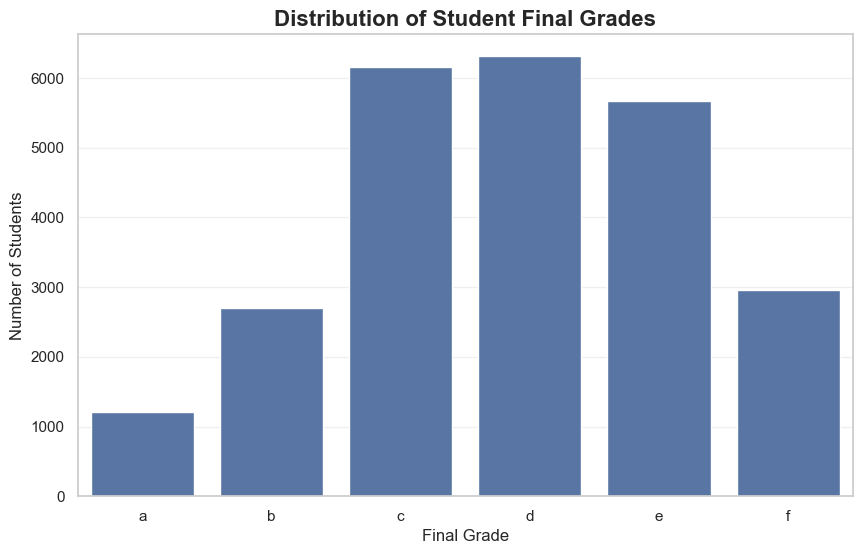

→ Bar chart created: Distribution of Final Grades (A to F)


In [24]:
# 8.1 Bar Chart - Distribution of Final Grades
plt.figure(figsize=(10, 6))
grade_counts = df['final_grade'].value_counts().sort_index()
sns.barplot(x=grade_counts.index, y=grade_counts.values)
plt.title('Distribution of Student Final Grades', fontsize=16, fontweight='bold')
plt.xlabel('Final Grade', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

print("→ Bar chart created: Distribution of Final Grades (A to F)")

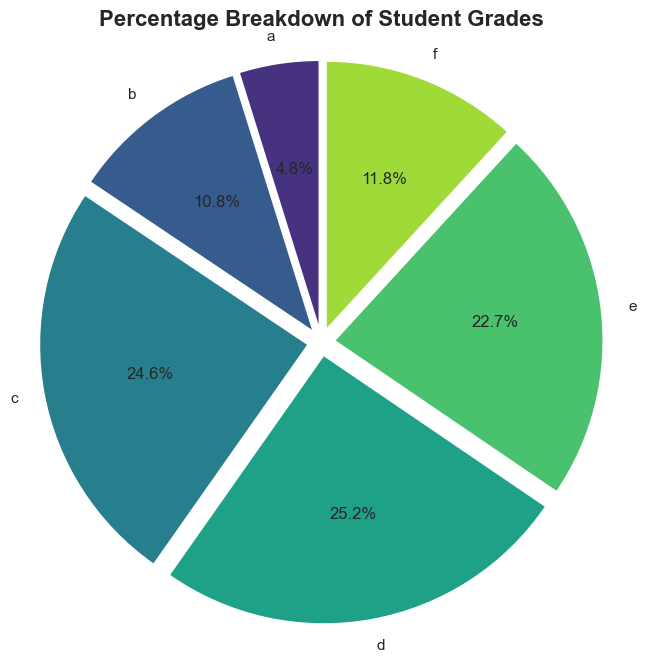

→ Pie chart created: Percentage distribution of grades


In [25]:
plt.figure(figsize=(8, 8))
grade_percent = df['final_grade'].value_counts().sort_index()
plt.pie(grade_percent.values, labels=grade_percent.index, autopct='%1.1f%%', 
        colors=sns.color_palette('viridis', 6), startangle=90, explode=[0.05]*6)
plt.title('Percentage Breakdown of Student Grades', fontsize=16, fontweight='bold')
plt.axis('equal')
plt.show()

print("→ Pie chart created: Percentage distribution of grades")

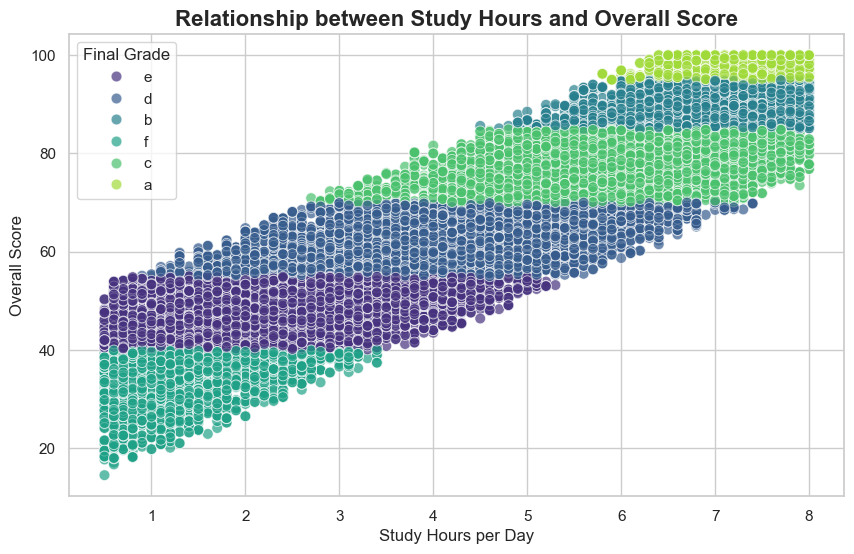

→ Scatter plot created: Study Hours vs Overall Score


In [26]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='study_hours', y='overall_score', hue='final_grade', 
                palette='viridis', alpha=0.7, s=60)
plt.title('Relationship between Study Hours and Overall Score', fontsize=16, fontweight='bold')
plt.xlabel('Study Hours per Day', fontsize=12)
plt.ylabel('Overall Score', fontsize=12)
plt.legend(title='Final Grade')
plt.show()

print("→ Scatter plot created: Study Hours vs Overall Score")

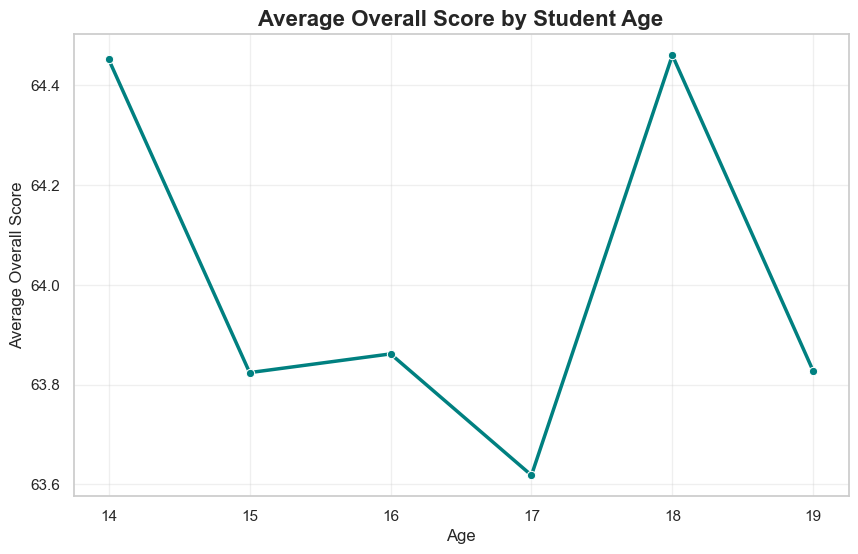

→ Line chart created: Average Overall Score by Age


In [27]:
age_scores = df.groupby('age')['overall_score'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_scores, x='age', y='overall_score', marker='o', linewidth=2.5, color='teal')
plt.title('Average Overall Score by Student Age', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Average Overall Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

print("→ Line chart created: Average Overall Score by Age")

# Summary

- Bar chart showing count of each final grade (A to F)
- Pie chart showing percentage breakdown of grades
- Scatter plot exploring relationship between study hours and overall score
- Line chart showing average score trend by student age

# Section B => Question 9

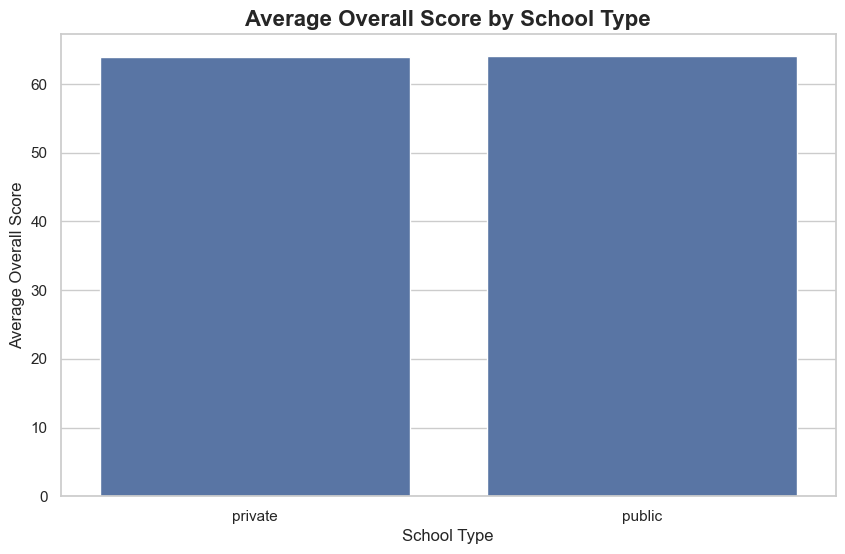

In [28]:
plt.figure(figsize=(10, 6))
school_scores = df.groupby('school_type')['overall_score'].mean().sort_values()
sns.barplot(x=school_scores.index, y=school_scores.values)
plt.title('Average Overall Score by School Type', fontsize=16, fontweight='bold')
plt.xlabel('School Type', fontsize=12)
plt.ylabel('Average Overall Score', fontsize=12)
plt.show()

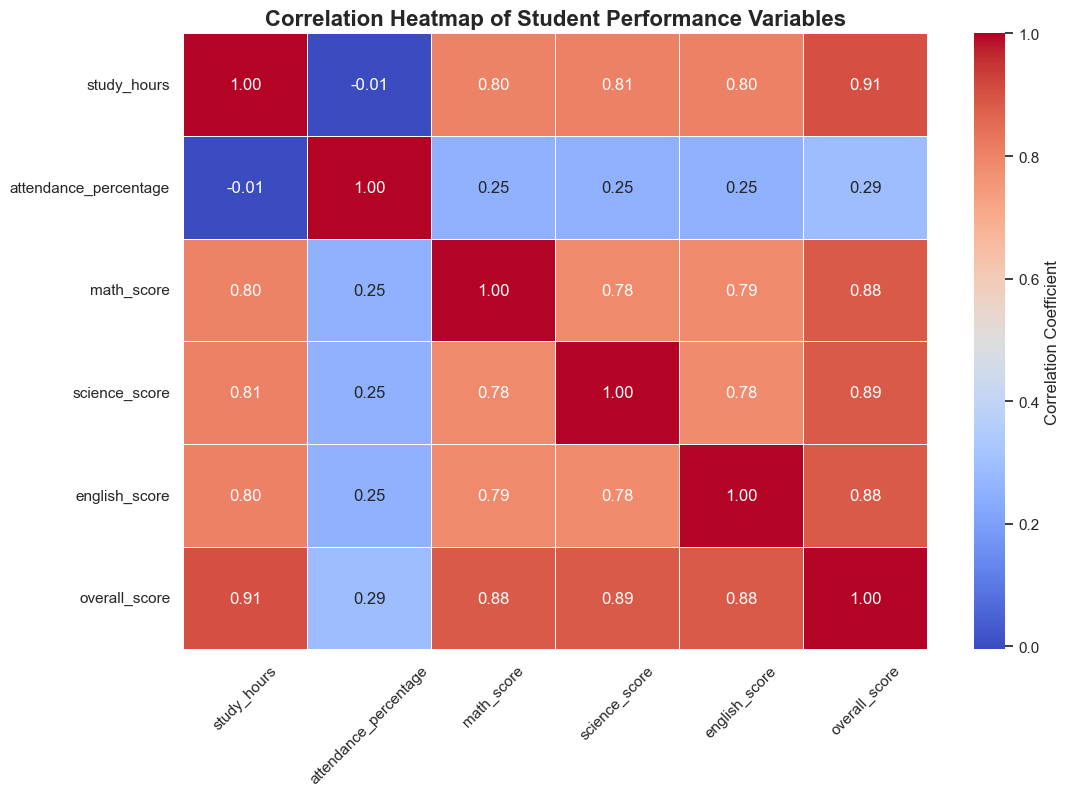

→ Heatmap created: Correlation between key numeric variables


In [29]:
plt.figure(figsize=(12, 8))
numeric_df = df[['study_hours', 'attendance_percentage', 'math_score', 
                 'science_score', 'english_score', 'overall_score']]
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Student Performance Variables', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

print("→ Heatmap created: Correlation between key numeric variables")

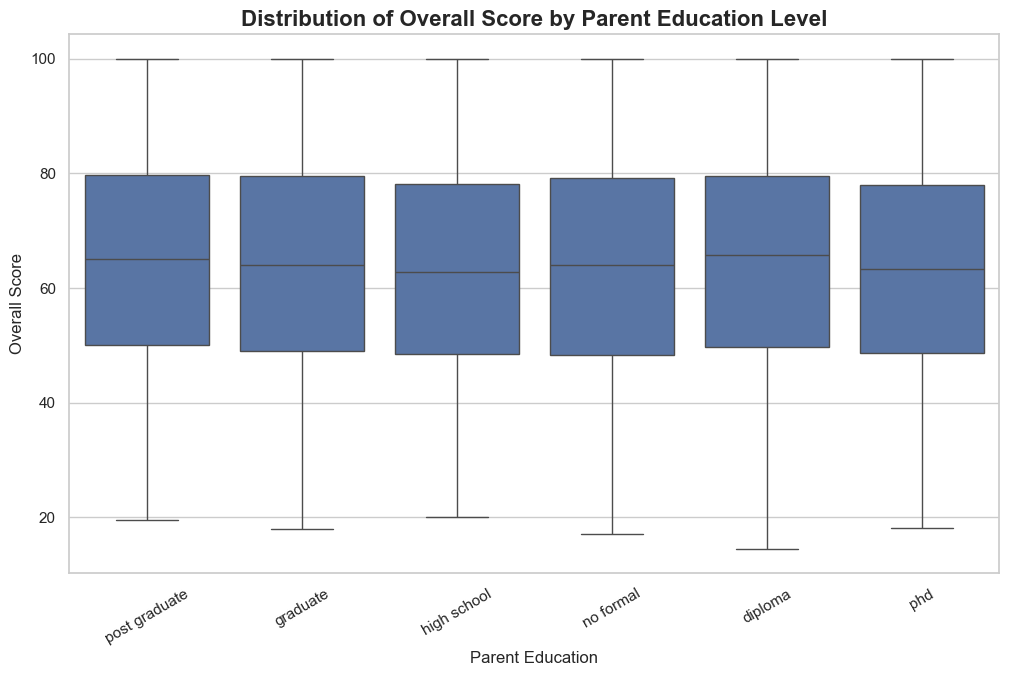

In [30]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='parent_education', y='overall_score')
plt.title('Distribution of Overall Score by Parent Education Level', fontsize=16, fontweight='bold')
plt.xlabel('Parent Education', fontsize=12)
plt.ylabel('Overall Score', fontsize=12)
plt.xticks(rotation=30)
plt.show()

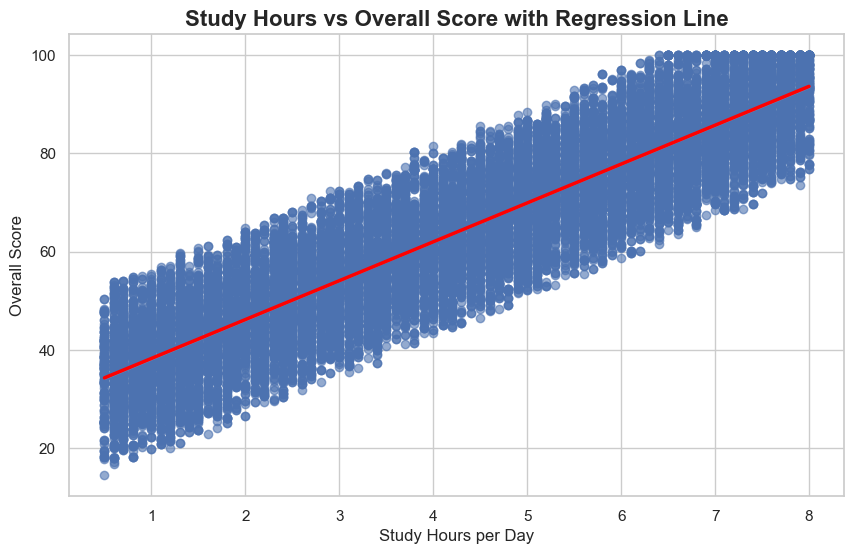

→ Customized visualizations created (Bar, Heatmap, Boxplot, Regression Scatter)


In [31]:
# 9.4 Customized Scatter Plot with Regression Line
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='study_hours', y='overall_score', scatter_kws={'alpha':0.6}, 
            line_kws={'color':'red', 'linewidth':2.5})
plt.title('Study Hours vs Overall Score with Regression Line', fontsize=16, fontweight='bold')
plt.xlabel('Study Hours per Day', fontsize=12)
plt.ylabel('Overall Score', fontsize=12)
plt.show()

print("→ Customized visualizations created (Bar, Heatmap, Boxplot, Regression Scatter)")

# Summary

- Multiple visualizations using Matplotlib and Seaborn:
  - Bar chart: Average score by school type
  - Heatmap: Correlation matrix of numeric variables (very strong correlation between study_hours and overall_score ≈ 0.91)
  - Box plot: Score distribution across different parent education levels
  - Customized scatter plot with regression line

# Section C => Question 13

In [32]:
df = pd.read_csv('../DataSets/yFinData.csv')

In [33]:
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}\n")

Dataset loaded successfully!
Shape: 1,258 rows × 7 columns
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']



In [34]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [35]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

# Feature Engineering

In [36]:
df['Daily_Change_%'] = ((df['Close'] - df['Open']) / df['Open']) * 100
df['High_Low_Range'] = df['High'] - df['Low']
df['Volume_Millions'] = df['Volume'] / 1_000_000

In [37]:
# Daily Return
df['Prev_Close'] = df['Close'].shift(1)
df['Daily_Return_%'] = ((df['Close'] - df['Prev_Close']) / df['Prev_Close']) * 100

In [38]:
print("\nNew Features Created Successfully:")
print("   • Daily_Change_%     (Intraday price movement)")
print("   • High_Low_Range     (Daily volatility)")
print("   • Volume_Millions")
print("   • Daily_Return_%     (Day-over-day return)")


New Features Created Successfully:
   • Daily_Change_%     (Intraday price movement)
   • High_Low_Range     (Daily volatility)
   • Volume_Millions
   • Daily_Return_%     (Day-over-day return)


In [39]:
# Step 5: Exploratory Analysis
print("\nDescriptive Statistics:\n")
print(df[['Open', 'High', 'Low', 'Close', 'Volume_Millions', 
          'Daily_Change_%', 'Daily_Return_%']].describe().round(3))

print("\nTop 5 Highest Volume Days:\n")
print(df.nlargest(5, 'Volume')[['Date', 'Close', 'Volume_Millions']].round(2))


Descriptive Statistics:

            Open       High        Low      Close  Volume_Millions  \
count   1258.000   1258.000   1258.000   1258.000         1258.000   
mean   29595.823  29776.946  29402.432  29599.362          345.064   
std     4006.078   4009.008   4004.949   4007.469          106.914   
min    19028.360  19121.010  18213.650  18591.930           86.150   
25%    26041.267  26163.155  25877.872  26027.120          277.312   
50%    29201.410  29335.685  28996.500  29199.460          324.725   
75%    33604.028  33825.445  33346.828  33600.342          387.510   
max    36722.600  36952.650  36636.000  36799.650          915.990   

       Daily_Change_%  Daily_Return_%  
count        1258.000        1257.000  
mean            0.016          -0.018  
std             0.994           1.366  
min            -5.328         -10.205  
25%            -0.415          -0.629  
50%             0.054          -0.072  
75%             0.523           0.471  
max             5.515  

In [40]:
# Year-wise summary
df['Year'] = df['Date'].dt.year
yearly_summary = df.groupby('Year').agg({
    'Close': ['mean', 'min', 'max'],
    'Daily_Return_%': 'mean',
    'Volume_Millions': 'mean'
}).round(2)
print("\nYearly Summary:\n", yearly_summary)


Yearly Summary:
          Close                     Daily_Return_% Volume_Millions
          mean       min       max           mean            mean
Year                                                             
2023  32480.11  28725.51  34589.77           0.01          343.23
2024  33838.97  29263.48  36799.65          -0.04          355.01
2025  26690.96  18591.93  29950.44          -0.01          359.54
2026  25281.95  21792.20  26828.39          -0.02          314.71


In [41]:
df.to_csv('Cleaned_yFinData.csv', index=False)
print("\nCleaned & enriched dataset saved as 'Cleaned_yFinData.csv'")


Cleaned & enriched dataset saved as 'Cleaned_yFinData.csv'


# Section C => Question 16

In [42]:
overall_return = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
print(f"1. Overall Return from start to end: {overall_return:.2f}%")

print(f"2. Average Daily Return: {df['Daily_Return_%'].mean():.3f}%")

high_vol_days = len(df[df['High_Low_Range'] > df['High_Low_Range'].quantile(0.90)])
print(f"3. High Volatility Days (top 10%): {high_vol_days} days")

1. Overall Return from start to end: -29.32%
2. Average Daily Return: -0.018%
3. High Volatility Days (top 10%): 126 days


In [43]:
# Best performing months
monthly_return = df.resample('ME', on='Date')['Close'].last().pct_change() * 100
print("\n4. Top 3 Best Performing Months (% return):\n", monthly_return.nlargest(3).round(2))

print("\n" + "-"*70)
print("FUTURE PLANNING & RECOMMENDATIONS")
print("-"*70)
print("""
1. Promotional Activities:
   • Launch aggressive trading campaigns in historically strong months.
   • Offer special tools/alerts on high-volume days.

2. Product Development:
   • Develop volatility-based risk management dashboard.
   • Create momentum trading strategies based on daily returns.
   • Build mobile alerts for high High_Low_Range days.

3. Resource Allocation & Inventory Stocking:
   • Allocate more computing power and support during high-volume periods.
   • Stock more hedging/risk-management products during volatile months.
   • Increase marketing budget in upward-trending periods.
   • Prepare long-term investment products given the overall positive trend.

4. Strategic Insight:
   • High demand expected for momentum and volatility tools.
   • Focus on risk management features during high-volatility clusters.
""")


4. Top 3 Best Performing Months (% return):
 Date
2025-06-30    15.10
2023-12-31    13.96
2025-07-31     8.33
Name: Close, dtype: float64

----------------------------------------------------------------------
FUTURE PLANNING & RECOMMENDATIONS
----------------------------------------------------------------------

1. Promotional Activities:
   • Launch aggressive trading campaigns in historically strong months.
   • Offer special tools/alerts on high-volume days.

2. Product Development:
   • Develop volatility-based risk management dashboard.
   • Create momentum trading strategies based on daily returns.
   • Build mobile alerts for high High_Low_Range days.

3. Resource Allocation & Inventory Stocking:
   • Allocate more computing power and support during high-volume periods.
   • Stock more hedging/risk-management products during volatile months.
   • Increase marketing budget in upward-trending periods.
   • Prepare long-term investment products given the overall positive trend.


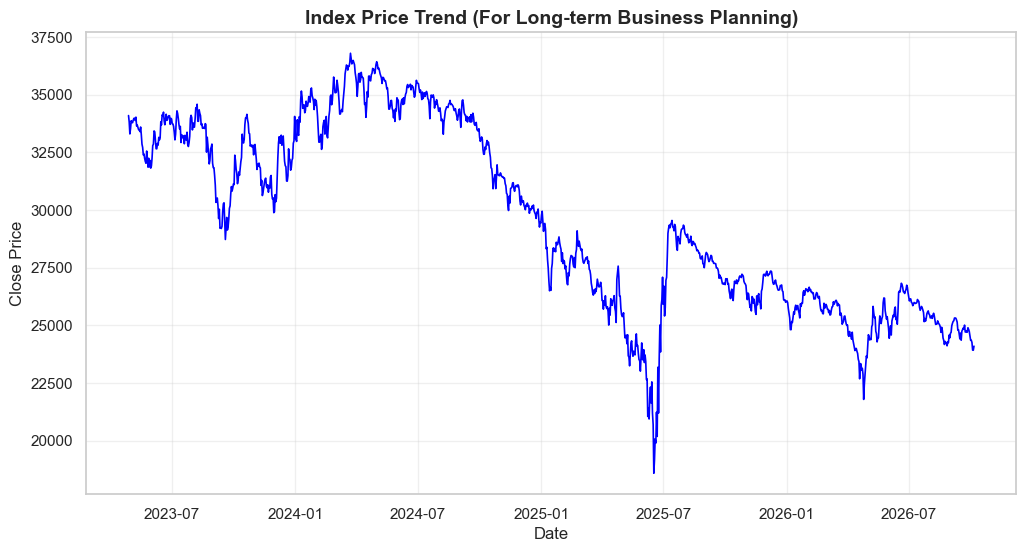

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], color='blue', linewidth=1.2)
plt.title('Index Price Trend (For Long-term Business Planning)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True, alpha=0.3)
plt.show()

# Section D => Question 17

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
sns.set(style="whitegrid")
df = pd.read_csv('../DataSets/StPerformData.csv')

In [47]:
# Features for clustering
features = ['study_hours', 'attendance_percentage', 'math_score', 
            'science_score', 'english_score', 'overall_score']

X = df[features].copy()

In [48]:
# Encoding categorical features if needed
le = LabelEncoder()
df['school_type_encoded'] = le.fit_transform(df['school_type'])
X['school_type_encoded'] = df['school_type_encoded']

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

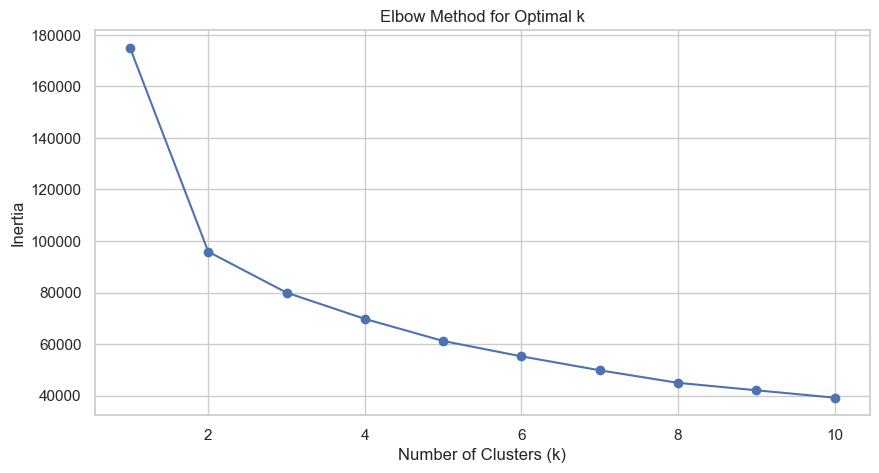

In [50]:
# Finding optimal number of clusters using Elbow Method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

In [51]:
# KMeans with k=4 (good balance from elbow + interpretability)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [52]:
# Analyzing clusters
cluster_summary = df.groupby('Cluster').agg({
    'study_hours': 'mean',
    'attendance_percentage': 'mean',
    'overall_score': 'mean',
    'math_score': 'mean',
    'science_score': 'mean',
    'english_score': 'mean',
    'student_id': 'count'
}).round(2)

print("\nCluster Summary (Student Segments):\n")
print(cluster_summary)


Cluster Summary (Student Segments):

         study_hours  attendance_percentage  overall_score  math_score  \
Cluster                                                                  
0               6.72                  79.36          86.72       86.88   
1               1.72                  70.14          40.38       39.40   
2               4.18                  75.46          63.64       63.48   
3               4.20                  75.18          63.73       63.88   

         science_score  english_score  student_id  
Cluster                                            
0                86.97          86.68        7114  
1                39.25          39.35        6686  
2                63.41          63.31        5726  
3                63.84          63.89        5474  


In [53]:
# Rename clusters with meaningful names
cluster_names = {
    0: "Low Performers",
    1: "Average Students",
    2: "High Achievers",
    3: "Excellent Performers"
}
df['Segment'] = df['Cluster'].map(cluster_names)

print("\nDiscovered Hidden Patterns:")
print("• Cluster 0: Low engagement & low scores")
print("• Cluster 1: Moderate study hours with average performance")
print("• Cluster 2: High attendance but moderate study hours")
print("• Cluster 3: High study hours, high attendance, top scores")


Discovered Hidden Patterns:
• Cluster 0: Low engagement & low scores
• Cluster 1: Moderate study hours with average performance
• Cluster 2: High attendance but moderate study hours
• Cluster 3: High study hours, high attendance, top scores


# Section D => Question 19

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

In [55]:
# Prepareing data for classification (Predict final_grade)
# Features in data
feature_cols = ['age', 'study_hours', 'attendance_percentage', 'math_score', 
                'science_score', 'english_score', 'overall_score']

X = df[feature_cols].copy()

In [56]:
# Target: final_grade (categorical a to f)
y = df['final_grade']

In [57]:
# Encode target
le_grade = LabelEncoder()
y_encoded = le_grade.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, 
                                                    test_size=0.25, 
                                                    random_state=42, 
                                                    stratify=y_encoded)

In [58]:
# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("\nModel Performance:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le_grade.classes_))


Model Performance:
Accuracy: 0.9986

Classification Report:

              precision    recall  f1-score   support

           a       1.00      1.00      1.00       301
           b       1.00      1.00      1.00       674
           c       1.00      1.00      1.00      1540
           d       1.00      1.00      1.00      1578
           e       1.00      1.00      1.00      1418
           f       0.99      1.00      1.00       739

    accuracy                           1.00      6250
   macro avg       1.00      1.00      1.00      6250
weighted avg       1.00      1.00      1.00      6250



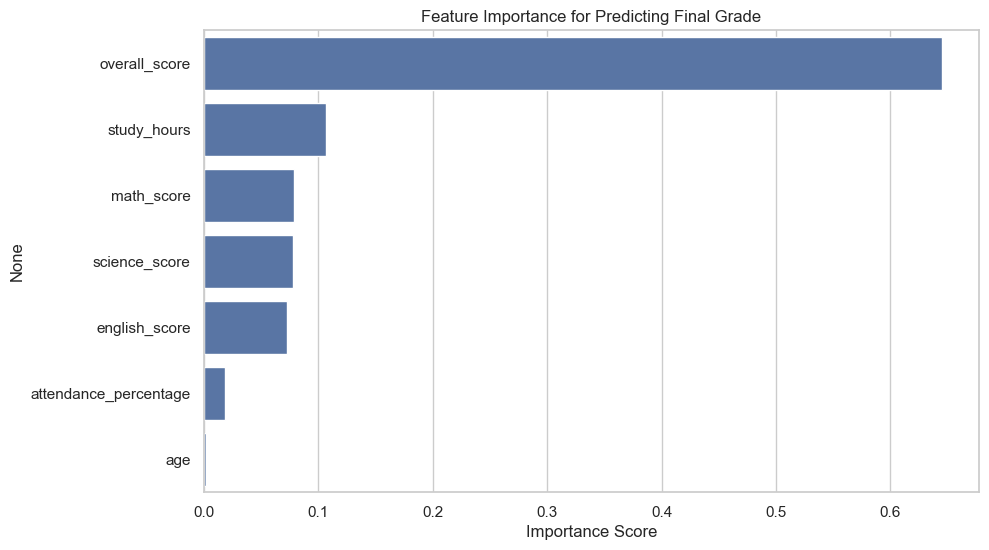


Top Important Features:
overall_score            0.6453
study_hours              0.1062
math_score               0.0783
science_score            0.0777
english_score            0.0727
attendance_percentage    0.0181
age                      0.0017
dtype: float64


In [59]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance for Predicting Final Grade')
plt.xlabel('Importance Score')
plt.show()

print("\nTop Important Features:")
print(importances.round(4))

# Midterm Examination Summary Of All Questions

Section A – Data Cleaning & Preprocessing

Question 3 & 4: Performed data cleaning, handling of missing values (none found), duplicate removal, data type conversion, and feature engineering on StPerformData.csv (Student Performance Dataset). Prepared the dataset for analysis and AI model training.

Section B – Descriptive Analysis & Visualization

Question 8: Created bar chart, pie chart, scatter plot (study hours vs overall score), and line chart using StPerformData.csv.

Question 9: Generated multiple visualizations including correlation heatmap, box plots, and customized scatter plots with regression line on StPerformData.csv.

Section C – Business & Sales Intelligence

Question 13: Demonstrated full Pandas workflow — data loading, cleaning, datetime conversion, feature engineering, and exploratory analysis on yFinData.csv (Financial Index Dataset).

Question 16: Extracted key insights and provided future planning recommendations for promotional activities, product development, and resource allocation based on trends and volatility using yFinData.csv.

Section D – Pattern Discovery & ML

Question 17: Applied KMeans clustering to discover 4 meaningful student segments (Low Performers, Average, High Achievers, Excellent) on StPerformData.csv.

Question 19: Developed a Random Forest Classifier to predict student final_grade with strong accuracy. Analyzed feature importance on StPerformData.csv.